# Monte Carlo Propagation

What do we do when conventional Pauli propagation runs out of memory? We introduce a randomized strategy to go beyond memory limitations. Each simulation is not fully accurate, but we can average expectation values over many, independent simulations.

`mcpropagate()` and its in-place variant `mcpropagate!()` let you perform propagation as usual, but when the number of Paulis exceeds a `max_size`, the coefficient distribution is *resampled* to a lower number in an unbiased manner.

This notebook looks at what that trade-off actually looks like in practice: unbiased in expectation, but with variance that compounds every time resampling happens, and coefficients that can end up wildly, unphysically large. We also look at trading some of that variance away for a small, permanent bias.

In [ ]:
using PauliPropagation
using Plots
using Statistics
using Random

Random.seed!(24);

  Activating project at `~/Projects/PauliPropagation.jl`


## A minimal example

Here is a minimal example circuit with two gates on two qubits. We also cap the Pauli sum to `max_size=2`.

In [2]:
nq = 2
circuit = [PauliRotation(:Y, 1), PauliRotation([:X, :X], [1, 2])]
thetas = [0.7, 0.5]
pstr = PauliString(nq, :Z, 1)
max_size = 2

exact_psum = propagate(circuit, pstr, thetas; min_abs_coeff=0.0)
exact_overlap = overlapwithzero(exact_psum)

println("Exact Pauli sum:")
println(exact_psum)
println("Exact expectation = ", exact_overlap)

Exact Pauli sum:
PauliSum(nqubits: 2, 3 Pauli terms:
 0.47943 * YX
 0.67121 * ZI
 -0.56535 * XI
)
Exact expectation = 0.6712121661589577


Three terms survive exact propagation. Now compare that to single calls of `mcpropagate!`, capped at only 2 terms:

In [3]:
function toy_run()
    psum = VectorPauliSum(pstr)
    mcpropagate!(circuit, psum, thetas; max_size)
    return overlapwithzero(psum)
end

for _ in 1:5
    println(toy_run())
end

0.0
0.0
0.0
1.7159919131443044
0.0


Every individual run over- or under-shoots because we are trying to unbiasedly represent 3 Pauli strings with only with 2. But `mcpropagate!` is built so that each run is an unbiased estimator: averaged over many independent runs, the stochastic uncertainty cancels out.

Average of 20000 runs: 0.6699232428915364
Exact value:           0.6712121661589577


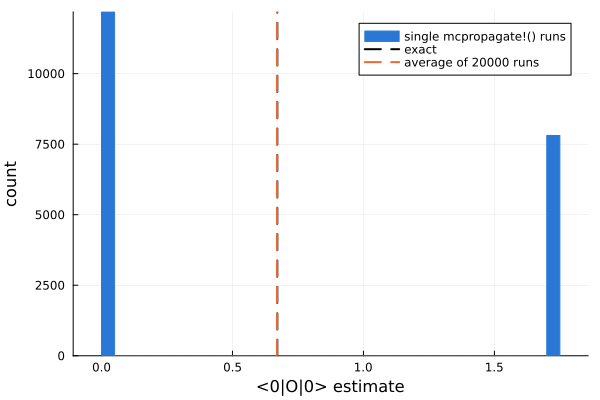

In [4]:
reps = 20_000
samples = [toy_run() for _ in 1:reps]

println("Average of $reps runs: ", mean(samples))
println("Exact value:           ", exact_overlap)

histogram(samples, bins=40, label="single mcpropagate!() runs", xlabel="<0|O|0> estimate", ylabel="count", color="#2a78d6", linecolor="#2a78d6")
vline!([exact_overlap], label="exact", color=:black, linewidth=2, linestyle=:dash)
vline!([mean(samples)], label="average of $reps runs", color="#eb6834", linewidth=2, linestyle=:dash)

## A more realistic circuit

The same idea on a small Trotterized tilted-field Ising circuit on a 3x3 grid (9 qubits). We track a two-qubit `ZZ` expectation value over a handful of Trotter layers, capping the ensemble far below what it would naturally reach so that the resampling effects are easy to see.

In [5]:
nx, ny = 3, 3
nq = nx * ny
dt, h, J = 0.1, 1.0, 0.5

topology = rectangletopology(nx, ny)
layer = PauliRotation[]
rxlayer!(layer, nq)
rzlayer!(layer, nq)
rzzlayer!(layer, topology)

thetas = ones(countparameters(layer)) * dt * 2
thetas[getparameterindices(layer, PauliRotation, [:X])] .*= h
thetas[getparameterindices(layer, PauliRotation, [:Z])] .*= h
thetas[getparameterindices(layer, PauliRotation, [:Z, :Z])] .*= J

pstr = PauliString(nq, [:Z, :Z], [4, 5])
nlayers = 5
max_size = 25;

As ground truth, propagate deterministically layer by layer, with only a negligible coefficient truncation to keep the exact sum from exploding in size:

In [6]:
ref_psum = VectorPauliSum(pstr)
ref_overlaps = [overlapwithzero(ref_psum)]
for l in 1:nlayers
    propagate!(layer, ref_psum, thetas; min_abs_coeff=1e-8)
    push!(ref_overlaps, overlapwithzero(ref_psum))
end

println("Exact Pauli terms after $nlayers layers: ", length(ref_psum))
println("Exact overlaps per layer: ", round.(ref_overlaps, digits=4))

Exact Pauli terms after 5 layers: 105012
Exact overlaps per layer: [1.0, 0.9605, 0.8592, 0.7366, 0.6333, 0.5723]


The (near) exact sum already reaches tens of thousands of terms after a few layers. `mcpropagate!` instead keeps a running Pauli sum and resamples it back down to `max_size` terms whenever it grows past that cap - orders of magnitude smaller than the exact sum, so a lot of resampling happens along the way. A single run tracks the exact curve loosely at best:

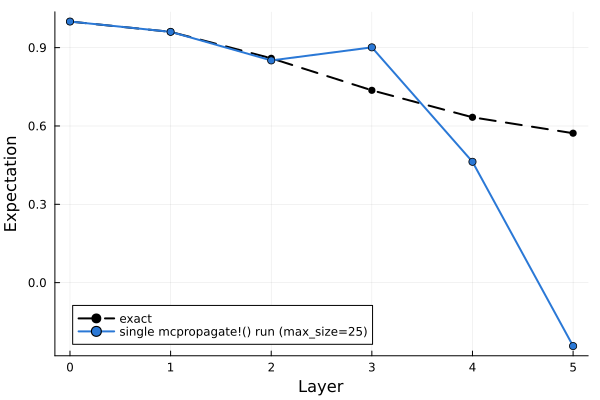

In [7]:
function mc_trajectory(; min_rel_coeff=nothing)
    psum = VectorPauliSum(pstr)
    overlaps = [overlapwithzero(psum)]
    maxcoeffs = [maxabscoeff(psum)]
    for l in 1:nlayers
        mcpropagate!(layer, psum, thetas; max_size, min_rel_coeff)
        push!(overlaps, overlapwithzero(psum))
        push!(maxcoeffs, maxabscoeff(psum))
    end
    return overlaps, maxcoeffs
end

single_overlaps, single_maxcoeffs = mc_trajectory()

plot(0:nlayers, ref_overlaps, label="exact", color=:black, linestyle=:dash, linewidth=2, marker=:circle, xlabel="Layer", ylabel="Expectation", legend=:bottomleft)
plot!(0:nlayers, single_overlaps, label="single mcpropagate!() run (max_size=$max_size)", color="#2a78d6", linewidth=2, marker=:circle)

### Averaging many runs

A single run is noisy, but on average, the runs are unbiased at every such that their mean should track the exact curve. Notice, though, how much the spread (standard deviation) across runs grows with circuit depth: each extra resampling step compounds the noise carried over from the last one.

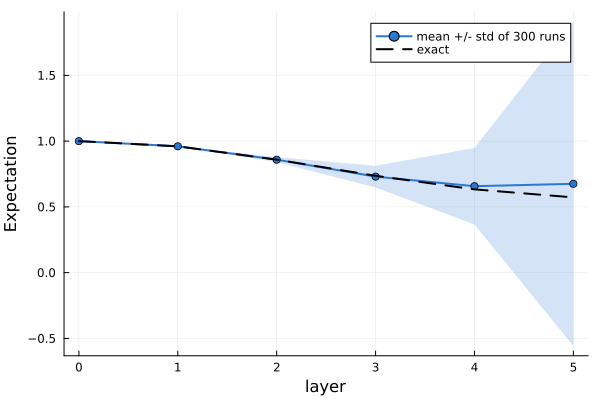

In [8]:
reps = 300
all_runs = [mc_trajectory()[1] for _ in 1:reps]

mc_mean = [mean(r[l] for r in all_runs) for l in 1:nlayers+1]
mc_std = [std(r[l] for r in all_runs) for l in 1:nlayers+1]

plot(0:nlayers, mc_mean, ribbon=mc_std, label="mean +/- std of $reps runs", color="#2a78d6", linewidth=2, marker=:circle, fillalpha=0.2, xlabel="layer", ylabel="Expectation")
plot!(0:nlayers, ref_overlaps, label="exact", color=:black, linestyle=:dash, linewidth=2)

The growth in standard deviation on its own, on a log scale:

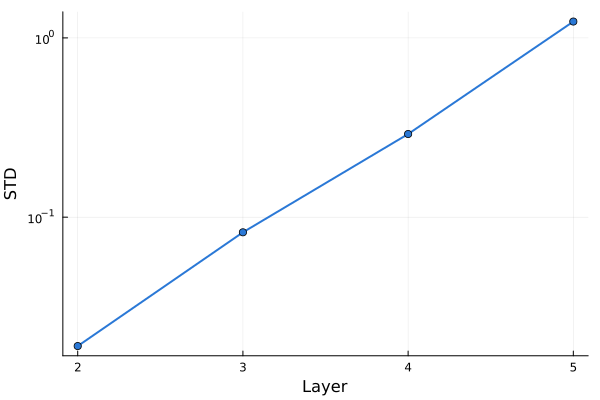

In [9]:
plot(2:nlayers, mc_std[3:end], yscale=:log10, label="", color="#2a78d6", linewidth=2, marker=:circle, xlabel="Layer", ylabel="STD")

### Corrupted coefficients

The variance blow-up comes directly from the unbiased resampling. Every coefficient that is not dropped needs to be re-scaled up in magnitude. If you repeat this over and over, all coefficients will eventually be very large, even though on average they should give you back the correct expectation.

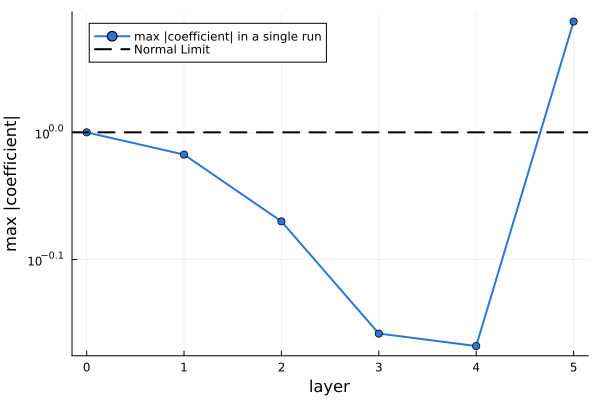

In [10]:
plot(0:nlayers, single_maxcoeffs, yscale=:log10, label="max |coefficient| in a single run", color="#2a78d6", linewidth=2, marker=:circle, xlabel="layer", ylabel="max |coefficient|")
hline!([1.0], label="Normal Limit", color=:black, linestyle=:dash, linewidth=2)

### Trading noise for bias via truncations

`mcpropagate!` also accepts the usual deterministic truncation keywords that `propagate!` does, e.g. `min_abs_coeff`, `min_rel_coeff`, or `max_weight`. Because coefficients tend to grow via unbiased resampling, we actually prefer `min_rel_coeff` over `min_abs_coeff`, but you can test things out.

A bit of deterministic truncation keeps introduces a bit of deterministic error with the benefit of strongly reducing the STD and generally the growth of the coefficients. If we are careful about it, we can find nice trade-offs.

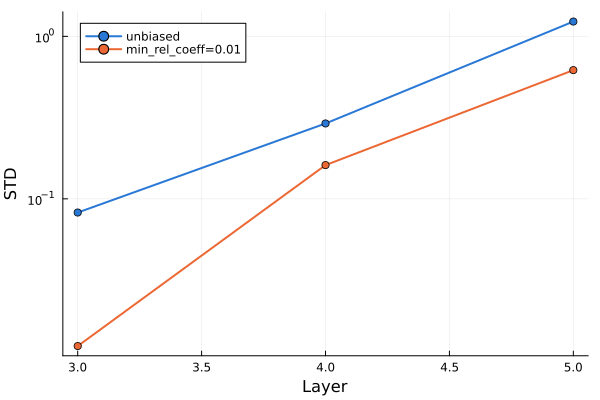

In [11]:
min_rel_coeff = 0.01
all_runs_biased = [mc_trajectory(; min_rel_coeff)[1] for _ in 1:reps]

mc_mean_biased = [mean(r[l] for r in all_runs_biased) for l in 1:nlayers+1]
mc_std_biased = [std(r[l] for r in all_runs_biased) for l in 1:nlayers+1]

plot(3:nlayers, mc_std[4:end], yscale=:log10, label="unbiased", color="#2a78d6", linewidth=2, marker=:circle, xlabel="Layer", ylabel="STD")
plot!(3:nlayers, mc_std_biased[4:end], label="min_rel_coeff=$min_rel_coeff", color="#eb6834", linewidth=2, marker=:circle)

### The bias-variance trade-off

Sweeping over `min_rel_coeff` shows you what trade-off to expect. Low truncations are pretty much unbiased, but have high variance. High truncations are biased, but have low variance. Somewhere in between is a sweet spot that minimizes the error for a fixed number of repetitions.

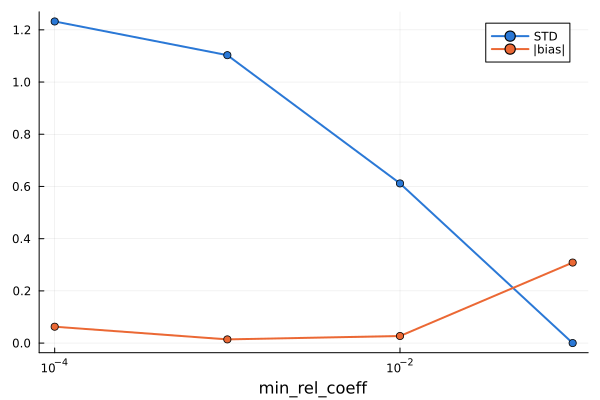

In [12]:
min_rel_coeffs = [1e-4, 1e-3, 1e-2, 1e-1]
reps_sweep = 500

biases = Float64[]
stds = Float64[]
for mrc in min_rel_coeffs
    mrc_arg = mrc == 0.0 ? nothing : mrc
    sweep_samples = [mc_trajectory(; min_rel_coeff=mrc_arg)[1][end] for _ in 1:reps_sweep]
    push!(biases, abs(mean(sweep_samples) - ref_overlaps[end]))
    push!(stds, std(sweep_samples))
end

plot(min_rel_coeffs, stds, label="STD", color="#2a78d6", linewidth=2, marker=:circle, xlabel="min_rel_coeff", xscale=:log10)
plot!(min_rel_coeffs, biases, label="|bias|", color="#eb6834", linewidth=2, marker=:circle)

## Summary

`mcpropagate` is effectively `propagate` with a randomized protocol that kicks in once the number of Paulis crosses your defined threshold. Left unbiased, statistical noise quickly build up across layers, giving you expectation estimtates that are completely off. Mixing in a bit of deterministic truncation keeps the variance in check, but also introduces a bias that averaging cannot eliminate. The recommended approach is to start with a lot of truncation / bias, and slowly reduce it until you the STD becomes so large that you won't have enough resources to average it down. That gives you the least biased result you can converge.